Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

Loading data

In [2]:
auto = pd.read_csv("auto_mpg .csv")

Obtain the basic description of data

In [5]:
auto.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


Check the first and the last rows of the dataset

In [6]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [7]:
auto.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


Examine numerical variables

In [9]:
numerical_features = auto.select_dtypes(include=[np.number])
numerical_features.columns

Index(['mpg', 'cylinders', 'displacement', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')

Examine categorical features

In [10]:
categorical_features = auto.select_dtypes(include=[object])
categorical_features.columns

Index(['horsepower', 'car name'], dtype='object')

checking missing values

In [11]:
auto.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

No missing values were detected using isnull().sum()

checking dataset info

In [12]:
auto.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


Considering the outputs, the only variable that needs to be converted is "horsepower" because although it contains numerical values,
it is stored as a categorical variable.

In [13]:
auto["horsepower"]= pd.to_numeric(auto["horsepower"], errors= "coerce")

In [14]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


After converting "horsepower" variable to a numerical variable, I create a dataset containing only numerical variables

In [15]:
numerical_auto = auto.select_dtypes(include=["number"])

Estimate Skewness and Kurtosis

In [17]:
numerical_auto.skew(), numerical_auto.kurt()

(mpg             0.457066
 cylinders       0.526922
 displacement    0.719645
 horsepower      1.087326
 weight          0.531063
 acceleration    0.278777
 model year      0.011535
 origin          0.923776
 dtype: float64,
 mpg            -0.510781
 cylinders      -1.376662
 displacement   -0.746597
 horsepower      0.696947
 weight         -0.785529
 acceleration    0.419497
 model year     -1.181232
 origin         -0.817597
 dtype: float64)

The dataset shows a moderate positive skewness for most variables. 
Horsepower has the highest positive skewness, while MPG has the lowest skewness value
Considering Kurtosis, most variables have negative values, suggesting a relatively flat distribution with fewer outliers 
compared to a normal distribution.
    

Creation of the correlation heatmap

<Axes: >

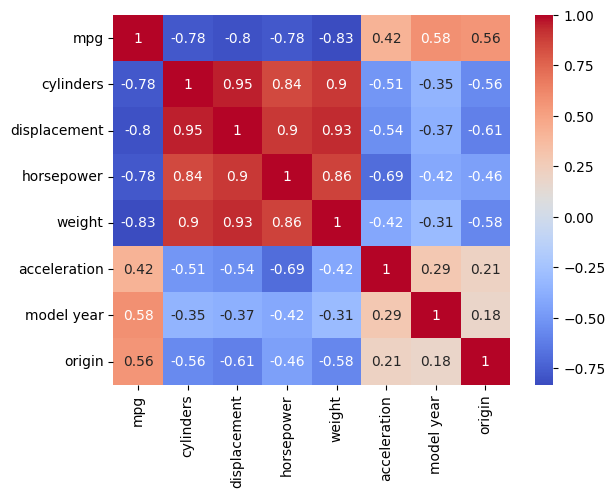

In [29]:
sns.heatmap(numerical_auto.corr(), annot=True, cmap="coolwarm")

The correlation heatmap shows strong relationships between the variables. MPG is strongly negatively correlated with weight(-0.83), dispalcement (-0.8), horsepower (- 0.78) and cylinders (-0.78), suggesting that heavier and more powerful cars tend to have lower fuel efficiency. MPG has moderate positive correlation with model year (0.58) and origin (0.56) suggesting that newer cars and cars from certain regions tend to achieve better fuel economy.

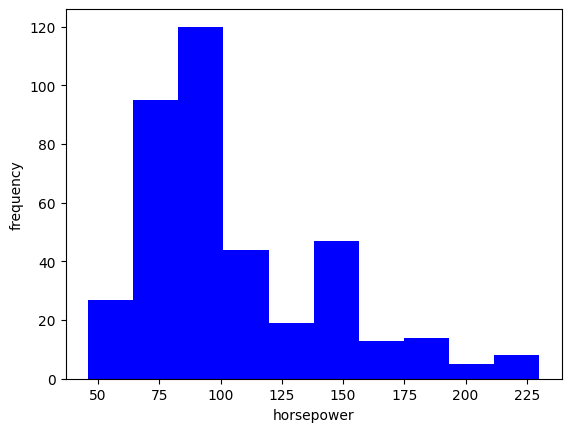

In [30]:
plt.hist(auto['horsepower'], histtype = 'bar', color = 'blue')
plt.xlabel("horsepower")
plt.ylabel("frequency")
plt.show()

The histogram shows that most vehicles have horsepower values between approximately 70 and 100. The distribution is positively skewed, suggesting that only a small number of vehicles have very high horsepower.

(array([13., 13., 59., 63., 95., 47., 25., 44., 20., 13.]),
 array([3.8286414 , 3.98958519, 4.15052898, 4.31147277, 4.47241656,
        4.63336035, 4.79430414, 4.95524794, 5.11619173, 5.27713552,
        5.43807931]),
 <BarContainer object of 10 artists>)

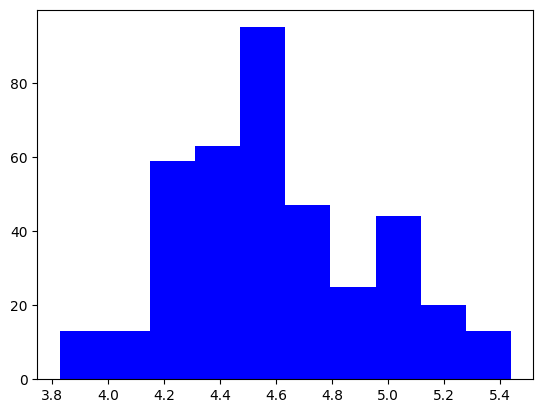

In [20]:
target = np.log(auto['horsepower'])
target.skew()
plt.hist(target, color='blue')

Applying a logarithmic transformation reduces the positive skewness and makes the distribution more symmetric.u

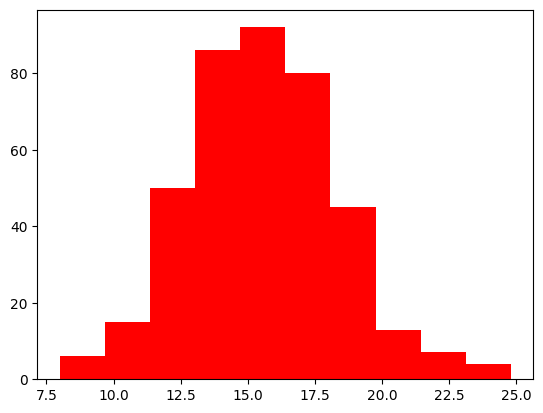

In [32]:
plt.hist(auto['acceleration'], histtype = 'bar', color = 'red')
target.skew()
plt.show()

The histogram of acceleration shows a symmetric distribution, with most vehicles having acceleration values between 13 and 18,

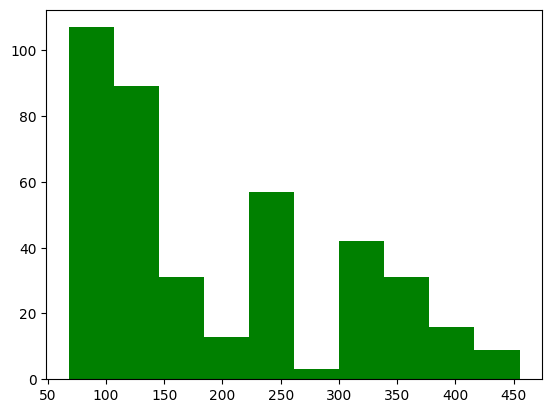

In [27]:
plt.hist(auto['displacement'], histtype = 'bar', color = 'green')
plt.show()

The histogram of displacement shows a positive skewed distribution, suggesting that most vehicles have relatively low to medium displacement values

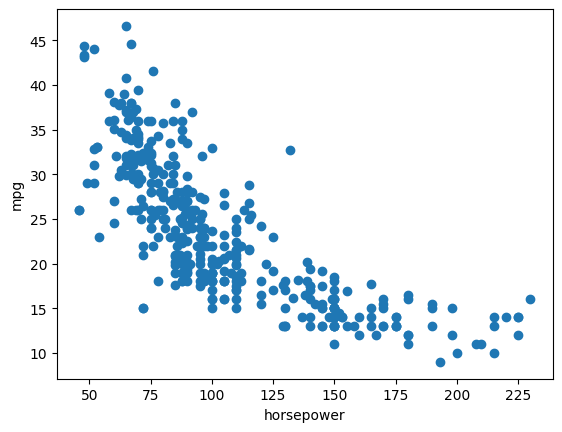

In [25]:
plt.scatter(auto["horsepower"], auto["mpg"])
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.show()

The scatter plot shows a strong negative relationship between horsepower and MPG. As horsepower increases, fuel efficiency generally decreases.

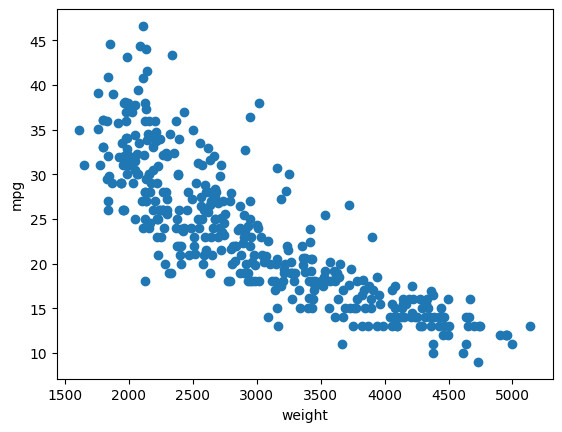

In [26]:
plt.scatter(auto["weight"], auto["mpg"])
plt.xlabel("weight")
plt.ylabel("mpg")
plt.show()

The scatter plot shows a strong negative relationship between weight and MPG. Heavier vehicles tend to have lower fuel efficiency, while lighter vehicles achieved higher MPG values.

The origin variable was already encoded as numerical values. However, the code to transform a categorical variable into a numerical value is as follows:

In [ ]:
auto["origin"] = auto["origin"].map({
    "USA": 1,
    "Europe":2,
    "Japan": 3
   
})